# A neural network from scratch (numpy)

A network with one hidden layer (2 inputs, a hidden layer, 1 output), trained with full-batch
gradient descent on the two-moons dataset. Plain numpy: forward pass, backward pass, update.

**Built for swapping.** Every activation and every loss is a `(function, derivative)` pair
stored in a dictionary, and the backward pass is the general chain rule. Any combination of
hidden activation, output activation and loss trains correctly, with no other code changes.

How to use it:

1. Change the names in `CONFIG` (section 4) and rerun from that cell down.
2. To add your own activation or loss: write the function and its derivative, add the pair to
   `ACTIVATIONS` or `LOSSES`, and run the **gradient check** (section 3) before training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import make_moons

SEED = 509
RED, BLUE, ORANGE = "#D90012", "#0033A0", "#F2A800"  # Armenian flag colors
PROB_CMAP = LinearSegmentedColormap.from_list("blue_white_red", [BLUE, "white", RED])

## 1. Data

train (800, 2) (800, 1), test (200, 2) (200, 1)


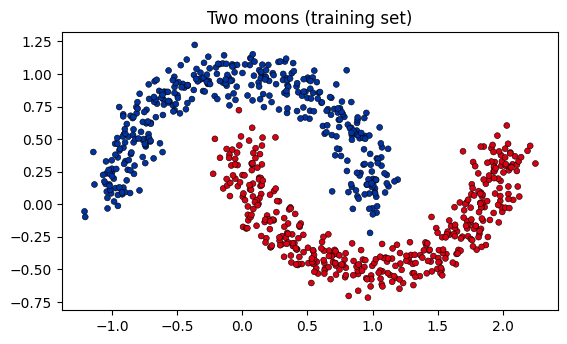

In [2]:
X, Y = make_moons(n_samples=1000, noise=0.1, random_state=SEED)

X_train, X_test = X[:800], X[800:]
Y_train, Y_test = Y[:800].reshape(-1, 1), Y[800:].reshape(-1, 1)
print(f"train {X_train.shape} {Y_train.shape}, test {X_test.shape} {Y_test.shape}")


def plot_data(X, Y, ax=None):
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=np.where(Y.ravel() == 1, RED, BLUE),
               edgecolors="k", linewidths=0.4, s=18)
    ax.set_aspect("equal")


plot_data(X_train, Y_train)
plt.title("Two moons (training set)")
plt.show()

## 2. The swappable parts

### Activations

Each activation is a pair `(f, df)`. **Convention: `df` takes the pre-activation `z`**, the same
input as `f`. Mixing conventions is a classic bug: `s * (1 - s)` is the sigmoid derivative only
if you pass it the *output* `s = sigmoid(z)`.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def leaky_relu(z, slope=0.01):
    return np.where(z > 0, z, slope * z)

def leaky_relu_derivative(z, slope=0.01):
    return np.where(z > 0, 1.0, slope)

def linear(z):
    return z

def linear_derivative(z):
    return np.ones_like(z)


ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_derivative),
    "tanh": (tanh, tanh_derivative),
    "relu": (relu, relu_derivative),
    "leaky_relu": (leaky_relu, leaky_relu_derivative),
    "linear": (linear, linear_derivative),
}

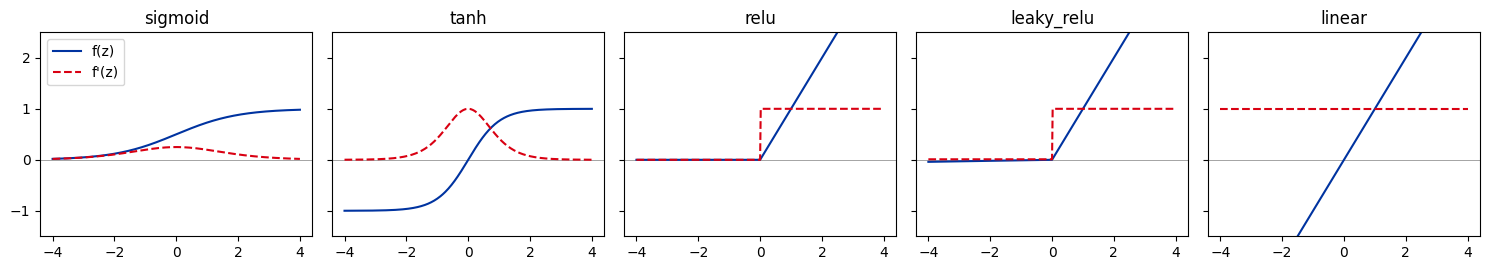

In [4]:
z = np.linspace(-4, 4, 401)
fig, axes = plt.subplots(1, len(ACTIVATIONS), figsize=(3 * len(ACTIVATIONS), 2.8), sharey=True)
for ax, (name, (f, df)) in zip(axes, ACTIVATIONS.items()):
    ax.axhline(0, color="gray", lw=0.5)
    ax.plot(z, f(z), color=BLUE, label="f(z)")
    ax.plot(z, df(z), color=RED, ls="--", label="f'(z)")
    ax.set_title(name)
    ax.set_ylim(-1.5, 2.5)
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

### Losses

A loss is also a pair `(L, dL)`. `L(Y, A)` returns one number; `dL(Y, A)` returns the gradient
with respect to the predictions `A`, same shape as `A`. Both **average over the batch**, so the
`1/N` lives here and nowhere else (the backward pass does not divide by `N` again).

Binary cross-entropy takes logs of `A` and `1 - A`, so it only makes sense when the output
activation is a sigmoid. `compatible()` enforces that instead of letting `np.clip` hide it.

In [5]:
EPS = 1e-12

def mse(Y, A):
    return np.mean((A - Y) ** 2)

def mse_derivative(Y, A):
    return 2 * (A - Y) / Y.size

def bce(Y, A):
    A = np.clip(A, EPS, 1 - EPS)
    return -np.mean(Y * np.log(A) + (1 - Y) * np.log(1 - A))

def bce_derivative(Y, A):
    A = np.clip(A, EPS, 1 - EPS)
    return (A - Y) / (A * (1 - A) * Y.size)


LOSSES = {
    "mse": (mse, mse_derivative),
    "bce": (bce, bce_derivative),
}


def compatible(output_activation, loss):
    return loss != "bce" or output_activation == "sigmoid"

### Initialization

Both scale random normal weights by the layer's size, so the signal neither explodes nor dies
as it passes through the layers. He (2015) is designed for ReLU; Xavier/Glorot (2010) for
tanh and sigmoid.

In [6]:
def he_init(fan_in, fan_out, rng):
    return rng.normal(size=(fan_in, fan_out)) * np.sqrt(2 / fan_in)

def xavier_init(fan_in, fan_out, rng):
    return rng.normal(size=(fan_in, fan_out)) * np.sqrt(2 / (fan_in + fan_out))


INITS = {"he": he_init, "xavier": xavier_init}

## 3. The network

Shapes, with `N` samples and `H` hidden units: `X` is `(N, 2)`, `W1` is `(2, H)`, `W2` is
`(H, 1)`. Rows are samples, so a layer is `Z = X @ W + b`.

`backward` is the chain rule, one layer at a time, and it never assumes which activation or loss
is used:

$$
\frac{\partial L}{\partial Z_2} = \underbrace{\frac{\partial L}{\partial A_2}}_{\texttt{dL}}
\odot \underbrace{f_2'(Z_2)}_{\texttt{df2}}, \qquad
\frac{\partial L}{\partial Z_1} = \left(\frac{\partial L}{\partial Z_2} W_2^\top\right) \odot f_1'(Z_1)
$$

In [7]:
def check_config(cfg):
    for key, table in [("hidden_activation", ACTIVATIONS), ("output_activation", ACTIVATIONS),
                       ("loss", LOSSES), ("init", INITS)]:
        if cfg[key] not in table:
            raise ValueError(f"{key}={cfg[key]!r} is not one of {list(table)}")
    if not compatible(cfg["output_activation"], cfg["loss"]):
        raise ValueError(f"loss='bce' needs predictions in (0, 1): use output_activation='sigmoid', "
                         f"not {cfg['output_activation']!r}")


def initialize_weights(input_size, hidden_size, output_size, init, seed):
    rng = np.random.default_rng(seed)
    init_fn = INITS[init]
    return {
        "W1": init_fn(input_size, hidden_size, rng),
        "b1": np.zeros((1, hidden_size)),
        "W2": init_fn(hidden_size, output_size, rng),
        "b2": np.zeros((1, output_size)),
    }


def forward(X, weights, cfg):
    f1, _ = ACTIVATIONS[cfg["hidden_activation"]]
    f2, _ = ACTIVATIONS[cfg["output_activation"]]
    Z1 = X @ weights["W1"] + weights["b1"]
    A1 = f1(Z1)
    Z2 = A1 @ weights["W2"] + weights["b2"]
    A2 = f2(Z2)
    return A2, (Z1, A1, Z2, A2)


def backward(X, Y, weights, cache, cfg):
    Z1, A1, Z2, A2 = cache
    _, df1 = ACTIVATIONS[cfg["hidden_activation"]]
    _, df2 = ACTIVATIONS[cfg["output_activation"]]
    _, dL = LOSSES[cfg["loss"]]

    dA2 = dL(Y, A2)               # dLoss/dA2, already averaged over the batch
    dZ2 = dA2 * df2(Z2)           # through the output activation
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)

    dA1 = dZ2 @ weights["W2"].T   # send the error back through W2
    dZ1 = dA1 * df1(Z1)           # through the hidden activation
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


def update_weights(weights, grads, learning_rate):
    for key in weights:
        weights[key] -= learning_rate * grads[key]
    return weights

### Gradient check

The one test that catches a wrong derivative. Nudge each weight by $\pm h$, measure how the loss
changes, and compare with what `backward` computed:

$$
\frac{\partial L}{\partial w} \approx \frac{L(w + h) - L(w - h)}{2h}
$$

A wrong derivative does **not** raise an error: training still runs, it just learns badly. So
this cell raises if any combination disagrees. It checks every pair of hidden and output
activation with every compatible loss, so a newly added activation or loss is covered
automatically.

In [8]:
def numeric_gradients(X, Y, weights, cfg, h=1e-6):
    loss_fn, _ = LOSSES[cfg["loss"]]
    grads = {}
    for key, W in weights.items():
        g = np.zeros_like(W)
        for idx in np.ndindex(W.shape):
            original = W[idx]
            W[idx] = original + h
            loss_plus = loss_fn(Y, forward(X, weights, cfg)[0])
            W[idx] = original - h
            loss_minus = loss_fn(Y, forward(X, weights, cfg)[0])
            W[idx] = original
            g[idx] = (loss_plus - loss_minus) / (2 * h)
        grads[key] = g
    return grads


def gradient_check(n_samples=20, hidden_size=4):
    X_small, Y_small = X_train[:n_samples], Y_train[:n_samples]
    rng = np.random.default_rng(SEED)
    failures, worst, n_checked = [], 0.0, 0
    for hidden in ACTIVATIONS:
        for output in ACTIVATIONS:
            for loss in LOSSES:
                if not compatible(output, loss):
                    continue
                cfg = {"hidden_activation": hidden, "output_activation": output, "loss": loss}
                weights = initialize_weights(2, hidden_size, 1, "he", SEED)
                # Random biases, not zeros: with zero biases a sample whose hidden ReLUs are all
                # off gets Z2 = 0 exactly, the kink where ReLU has no derivative, and the
                # finite difference (slope 0.5) disagrees with the formula (slope 0) there.
                weights["b1"] = rng.normal(scale=0.1, size=weights["b1"].shape)
                weights["b2"] = rng.normal(scale=0.1, size=weights["b2"].shape)
                _, cache = forward(X_small, weights, cfg)
                analytic = backward(X_small, Y_small, weights, cache, cfg)
                numeric = numeric_gradients(X_small, Y_small, weights, cfg)
                for key in weights:
                    worst = max(worst, np.abs(analytic[key] - numeric[key]).max())
                    if not np.allclose(analytic[key], numeric[key], rtol=1e-4, atol=1e-7):
                        failures.append(f"{hidden} -> {output}, {loss}: d{key}")
                n_checked += 1
    if failures:
        raise AssertionError("gradient check failed for:\n  " + "\n  ".join(failures))
    print(f"gradient check passed for {n_checked} combinations "
          f"(largest |analytic - numeric| = {worst:.1e})")


gradient_check()

gradient check passed for 30 combinations (largest |analytic - numeric| = 2.9e-10)


## 4. Train one network

**Change these names and rerun from here.** A misspelled name or an incompatible pair
(e.g. `bce` with a `linear` output) raises a `ValueError` immediately, and a loss that turns into `nan`/`inf`
(learning rate too high) stops training with an error instead of silently plotting garbage.

In [9]:
CONFIG = {
    "hidden_size": 16,
    "hidden_activation": "relu",     # any key of ACTIVATIONS
    "output_activation": "sigmoid",  # any key of ACTIVATIONS
    "loss": "bce",                   # any key of LOSSES ("bce" needs a sigmoid output)
    "init": "he",                    # any key of INITS
    "learning_rate": 1.0,
    "epochs": 3000,
    "seed": SEED,
}

In [10]:
def train(X, Y, cfg, X_val, Y_val, log_every=500):
    check_config(cfg)
    loss_fn, _ = LOSSES[cfg["loss"]]
    weights = initialize_weights(X.shape[1], cfg["hidden_size"], Y.shape[1], cfg["init"], cfg["seed"])
    history = {"train": [], "val": []}

    for epoch in range(cfg["epochs"]):
        A2, cache = forward(X, weights, cfg)
        loss = loss_fn(Y, A2)
        if not np.isfinite(loss):
            raise FloatingPointError(f"loss is {loss} at epoch {epoch}: "
                                     f"learning_rate={cfg['learning_rate']} is probably too high")
        history["train"].append(loss)
        history["val"].append(loss_fn(Y_val, forward(X_val, weights, cfg)[0]))

        grads = backward(X, Y, weights, cache, cfg)
        weights = update_weights(weights, grads, cfg["learning_rate"])

        if log_every and epoch % log_every == 0:
            print(f"epoch {epoch:5d}  train loss {loss:.4f}  test loss {history['val'][-1]:.4f}")

    return weights, history


def predict_proba(X, weights, cfg):
    return forward(X, weights, cfg)[0]

def predict(X, weights, cfg, threshold=0.5):
    return (predict_proba(X, weights, cfg) > threshold).astype(int)

def accuracy(X, Y, weights, cfg):
    return np.mean(predict(X, weights, cfg) == Y)


def plot_decision_boundary(weights, cfg, X, Y, ax=None):
    ax = ax or plt.gca()
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                         np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
    P = predict_proba(np.c_[xx.ravel(), yy.ravel()], weights, cfg).reshape(xx.shape)
    ax.contourf(xx, yy, P, levels=np.linspace(0, 1, 11), cmap=PROB_CMAP, alpha=0.45, extend="both")
    if P.min() < 0.5 < P.max():
        ax.contour(xx, yy, P, levels=[0.5], colors="k", linewidths=1.5)
    plot_data(X, Y, ax)


def plot_history(history, cfg, ax=None):
    ax = ax or plt.gca()
    ax.plot(history["train"], color=BLUE, label="train")
    ax.plot(history["val"], color=RED, ls="--", label="test")
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel(f"{cfg['loss']} loss (log scale)")
    ax.legend()

epoch     0  train loss 0.7048  test loss 0.6603


epoch   500  train loss 0.0140  test loss 0.0120


epoch  1000  train loss 0.0071  test loss 0.0070


epoch  1500  train loss 0.0050  test loss 0.0055


epoch  2000  train loss 0.0041  test loss 0.0050


epoch  2500  train loss 0.0034  test loss 0.0046



train accuracy 100.0%, test accuracy 100.0%


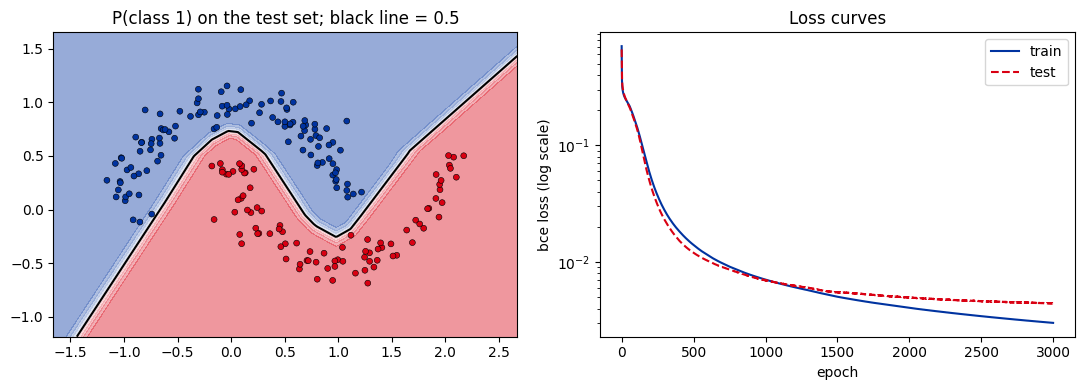

In [11]:
weights, history = train(X_train, Y_train, CONFIG, X_test, Y_test)
print(f"\ntrain accuracy {accuracy(X_train, Y_train, weights, CONFIG):.1%}, "
      f"test accuracy {accuracy(X_test, Y_test, weights, CONFIG):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_decision_boundary(weights, CONFIG, X_test, Y_test, axes[0])
axes[0].set_title("P(class 1) on the test set; black line = 0.5")
plot_history(history, CONFIG, axes[1])
axes[1].set_title("Loss curves")
plt.tight_layout()
plt.show()

## 5. Compare configurations

`compare` takes a list of *changes* to `CONFIG`, trains one network per entry, and draws each as a
column: the decision boundary on top, the loss curves below. Everything not listed stays as in
`CONFIG`, and every run starts from the same seed.

In [12]:
def compare(changes, base=CONFIG):
    fig, axes = plt.subplots(2, len(changes), figsize=(4.2 * len(changes), 8), squeeze=False)
    for col, change in enumerate(changes):
        cfg = {**base, **change}
        weights, history = train(X_train, Y_train, cfg, X_test, Y_test, log_every=0)
        label = ", ".join(f"{k}={v}" for k, v in change.items())
        test_acc = accuracy(X_test, Y_test, weights, cfg)
        print(f"{label:<55} final train loss {history['train'][-1]:.4f}  test accuracy {test_acc:.1%}")
        plot_decision_boundary(weights, cfg, X_test, Y_test, axes[0, col])
        axes[0, col].set_title(f"{label}\ntest accuracy {test_acc:.1%}", fontsize=10)
        plot_history(history, cfg, axes[1, col])
    plt.tight_layout()
    plt.show()

### Swap the hidden activation

hidden_activation=linear                                final train loss 0.2519  test accuracy 87.0%


hidden_activation=sigmoid                               final train loss 0.0238  test accuracy 100.0%


hidden_activation=tanh                                  final train loss 0.0037  test accuracy 100.0%


hidden_activation=relu                                  final train loss 0.0030  test accuracy 100.0%


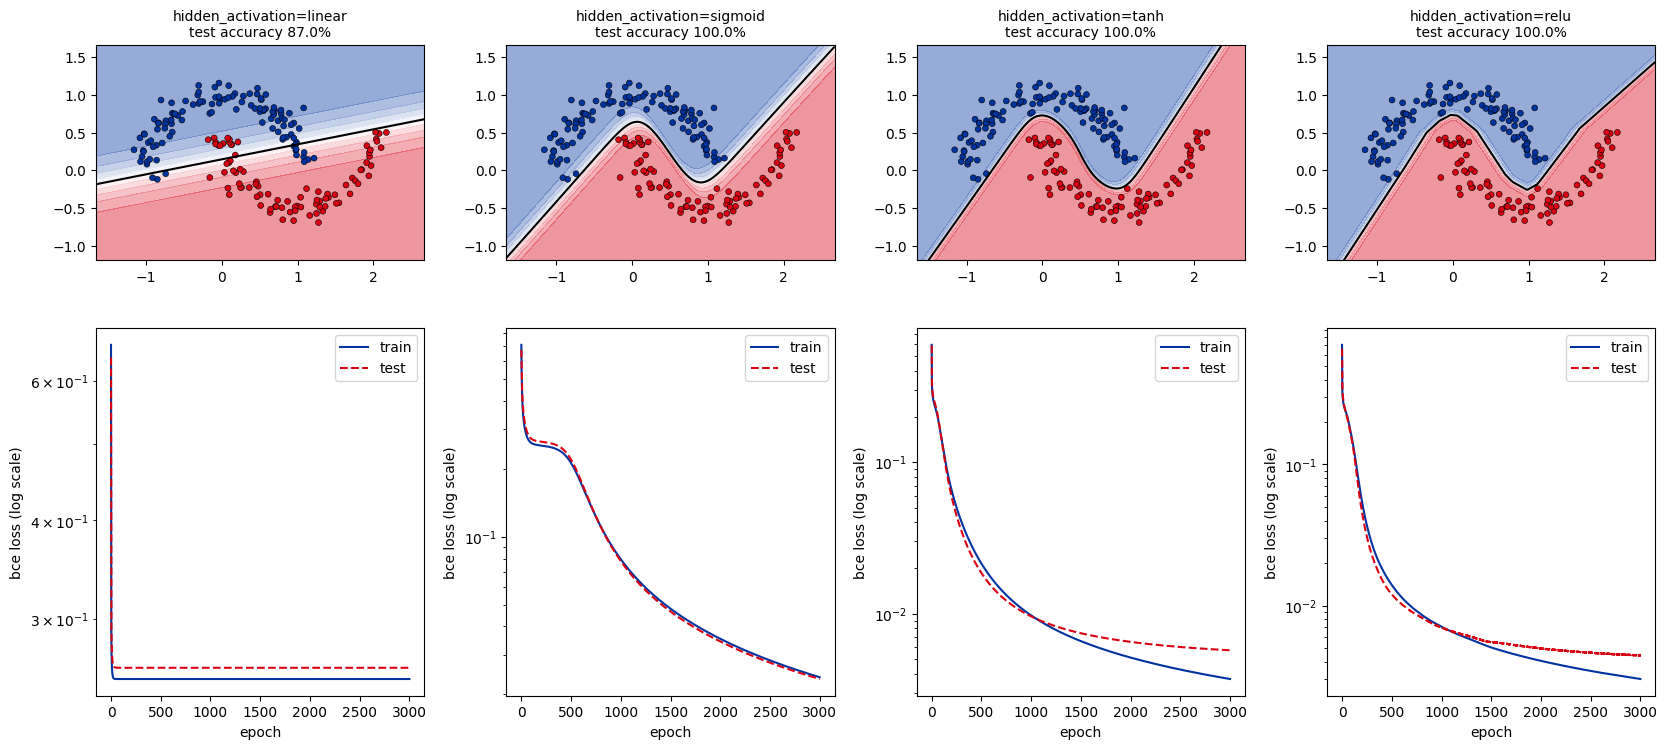

In [13]:
compare([{"hidden_activation": name} for name in ["linear", "sigmoid", "tanh", "relu"]])

**What happened** (seed 509, 16 hidden units, `learning_rate=1.0`, 3000 epochs):

- `linear`: 87% and a straight boundary. Without a nonlinearity the two layers collapse into one
  linear map, so this is logistic regression. Its loss flattens at 0.2519 within a few epochs and
  never moves again.
- `sigmoid`: 100%, but the slowest. The loss sits on a plateau for roughly the first 500 epochs
  (the sigmoid's derivative is never above 0.25, so every gradient passing through it shrinks)
  and ends at 0.0238.
- `tanh` and `relu`: 100%, final train loss 0.0037 and 0.0030. The `relu` boundary is visibly
  built from straight segments, one kink per hidden unit that switches on or off; `tanh` bends
  smoothly.

### Swap the loss

Why pair a sigmoid output with cross-entropy? Multiply the two derivatives, with $A = \sigma(Z)$:

$$
\underbrace{\frac{A - Y}{A(1 - A)\,N}}_{\text{bce}'} \cdot \underbrace{A(1 - A)}_{\sigma'}
= \frac{A - Y}{N}
\qquad \text{vs} \qquad
\underbrace{\frac{2(A - Y)}{N}}_{\text{mse}'} \cdot A(1 - A)
$$

With cross-entropy the $A(1 - A)$ cancels, and the gradient is just the error. With MSE it
stays, and $A(1 - A) \approx 0$ whenever the sigmoid saturates, **even when the prediction is
confidently wrong**, which is exactly when the network most needs to learn. The next cell checks
the cancellation numerically: the general chain rule in `backward` and the textbook shortcut
`(A - Y) / N` give the same `dZ2`.

In [14]:
cfg = {**CONFIG, "output_activation": "sigmoid", "loss": "bce"}
weights = initialize_weights(2, cfg["hidden_size"], 1, cfg["init"], cfg["seed"])
A2, (Z1, A1, Z2, _) = forward(X_train, weights, cfg)

chain_rule = bce_derivative(Y_train, A2) * sigmoid_derivative(Z2)
shortcut = (A2 - Y_train) / Y_train.size
print(f"max |chain rule - shortcut| = {np.abs(chain_rule - shortcut).max():.1e}")

max |chain rule - shortcut| = 1.1e-19


loss=bce                                                final train loss 0.0030  test accuracy 100.0%


loss=mse                                                final train loss 0.0016  test accuracy 100.0%


loss=mse, output_activation=linear, learning_rate=0.1   final train loss 0.0120  test accuracy 100.0%


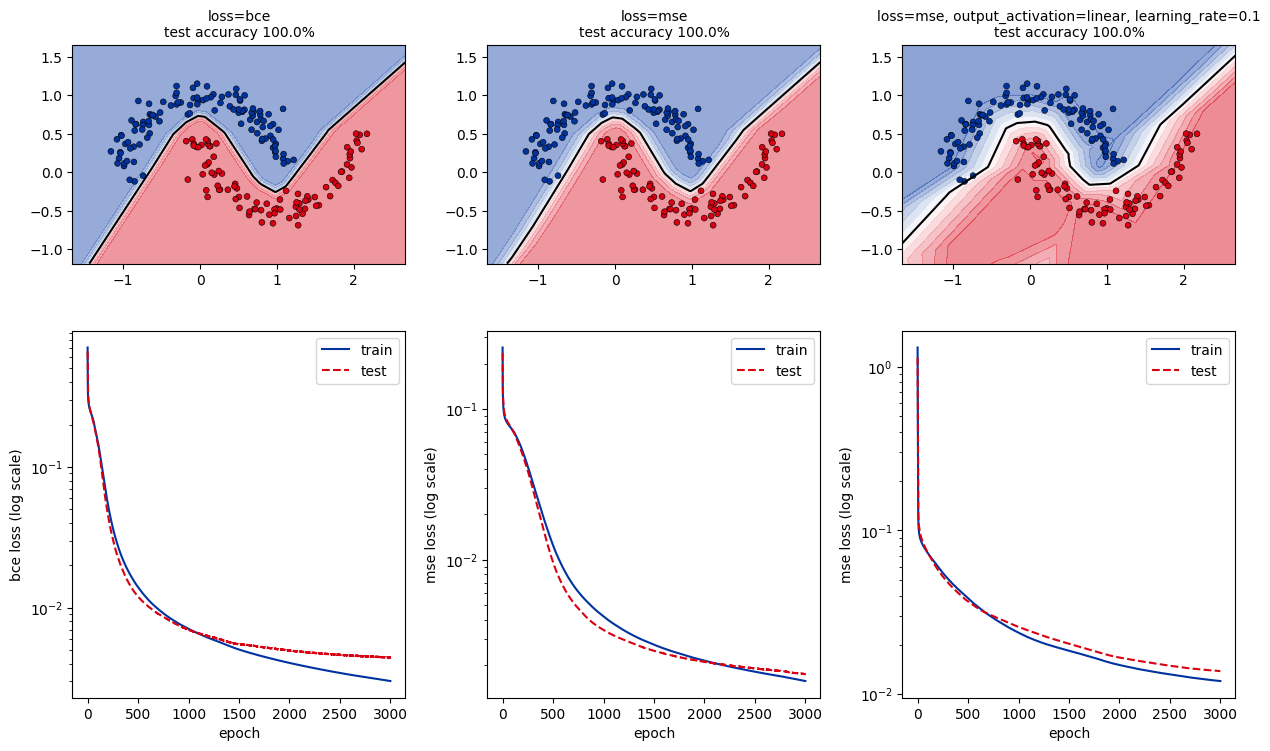

In [15]:
compare([
    {"loss": "bce"},
    {"loss": "mse"},
    {"loss": "mse", "output_activation": "linear", "learning_rate": 0.1},
])

**What happened:** all three reach 100% test accuracy with similar boundaries. How to read it:

- **Loss values in different columns are not comparable.** `bce` and `mse` measure different
  things, so mse's 0.0016 is not "better" than bce's 0.0030. Compare shapes and accuracy.
- **The saturation problem does not bite here.** Two moons is easy, and training starts with
  predictions near 0.5 (epoch-0 loss 0.70, about $\ln 2$), where $A(1-A)$ is at its largest. It
  shows up when the sigmoid is confidently wrong, e.g. after a bad initialization.
- **The `linear` output needed `learning_rate=0.1`.** Its output is unbounded, and at 1.0 the loss
  overflows to `inf` within a few epochs (exercise 4).

## 6. Your turn

1. **Add an activation.** `softplus(z) = log(1 + e^z)` is a smooth ReLU, and its derivative is
   the sigmoid. Write both functions, add `"softplus"` to `ACTIVATIONS`, rerun the gradient check,
   then add it to the activation comparison.
2. **Break the gradient check on purpose.** Change `tanh_derivative` to `1 - np.tanh(z)`, rerun
   the check, and read the error. Then see how training with the broken derivative looks.
3. **Width.** Set `hidden_size` to 3 in `CONFIG` with `relu`. It ends at exactly the `linear` column's loss (0.2519) and 87%: with this seed the
   network lands on the logistic-regression solution and stays there. Try other seeds, then
   8 units.
4. **Learning rate.** Run the MSE + `linear` output comparison with `learning_rate` 1.0. The loss
   overflows to `inf` at epoch 6 and `train` stops with an error.